# 🏥 04 — Modelos de Alta Performance: Accuracy & F1 > 80%

## ¿Por qué el notebook anterior dio ~66%?

| Problema | Efecto |
|---|---|
| Solo 10% de datos (1,470 filas train) | Underfitting severo, modelo no generaliza |
| Solo 5 features | Pierde información clave (Month, Day, Insurance Type...) |
| Threshold 0.19 | Modelo mal calibrado, predice casi todo como No-Show |

## Solución implementada

- ✅ **50% del dataset** (~7,300 filas train) — balance entre velocidad y rendimiento
- ✅ **Todas las features** (numéricas + one-hot de categóricas = ~35 columnas)
- ✅ **SMOTE solo en train** — test siempre con distribución real
- ✅ **Threshold calibrado** en conjunto de validación separado (no en test)
- ✅ **4 modelos** + **Stacking Ensemble** como modelo final
- ✅ **HistGradientBoosting** — más rápido y robusto con muchas features

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from pathlib import Path

from sklearn.model_selection import (
    train_test_split, RandomizedSearchCV, StratifiedKFold, cross_val_score
)
from sklearn.preprocessing import StandardScaler
from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import (
    RandomForestClassifier, HistGradientBoostingClassifier,
    StackingClassifier, GradientBoostingClassifier
)
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, f1_score, cohen_kappa_score,
    classification_report, confusion_matrix,
    roc_auc_score, precision_score, recall_score,
    balanced_accuracy_score, precision_recall_curve, auc, roc_curve
)
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
import lightgbm as lgb

np.random.seed(42)
print('✅ Librerías cargadas')

✅ Librerías cargadas


In [2]:
# ============================================================
# 📂 CARGA Y LIMPIEZA DEFENSIVA
# ============================================================
possible_paths = [
    Path('data/processed/df_limpio.csv'),
    Path('../data/processed/df_limpio.csv'),
    Path('../../data/processed/df_limpio.csv'),
]

df_limpio = None
for p in possible_paths:
    if p.exists():
        df_limpio = pd.read_csv(p)
        print(f'✅ Dataset cargado: {p.resolve()}  →  {df_limpio.shape}')
        break

if df_limpio is None:
    raise FileNotFoundError('No se encontró df_limpio.csv. Ejecuta 02_Limpieza.ipynb primero.')

# Eliminar columna de índice si existe
df_limpio.drop(columns=[c for c in df_limpio.columns if 'Unnamed' in str(c)], inplace=True)
df_limpio.columns = [str(c).strip() for c in df_limpio.columns]

# Detectar target de forma robusta
TARGET = None
for cand in ['Appointment Type', 'appointment_type', 'AppointmentType']:
    if cand in df_limpio.columns:
        TARGET = cand
        break
if TARGET is None:
    for col in df_limpio.columns:
        if set(df_limpio[col].dropna().unique()) <= {0, 1} and 0.20 <= df_limpio[col].mean() <= 0.50:
            TARGET = col
            break
if TARGET is None:
    raise ValueError(f'No se encontró target. Columnas: {df_limpio.columns.tolist()}')

print(f'✅ Target detectado: "{TARGET}"')
vc = df_limpio[TARGET].value_counts().sort_index()
print(f'   Clase 0 (Asistencia): {vc[0]:,}  ({vc[0]/len(df_limpio)*100:.1f}%)')
print(f'   Clase 1 (No-Show):    {vc[1]:,}  ({vc[1]/len(df_limpio)*100:.1f}%)')
print(f'   Total: {len(df_limpio):,} filas')

✅ Dataset cargado: C:\Users\alejo\Documents\SEMESTRE IX\Pdg - 2\predictive-no-show-fvl\notebooks\data\processed\df_limpio.csv  →  (18384, 13)
✅ Target detectado: "Appointment Type"
   Clase 0 (Asistencia): 12,111  (65.9%)
   Clase 1 (No-Show):    6,273  (34.1%)
   Total: 18,384 filas


In [3]:
# ============================================================
# 🔧 PREPARACIÓN DE FEATURES — TODAS LAS VARIABLES
# ============================================================

FEATURES_NUM = [c for c in [
    'Age', 'Number of Diseases', 'Recent Hospitalization',
    'Number of Medications', 'Hour', 'Creation to Assignment Interval',
    'Number of Previous Attendance', 'Number of Previous Non-Attendance'
] if c in df_limpio.columns]

FEATURES_CAT = [c for c in ['Sex', 'Insurance Type', 'Day', 'Month'] if c in df_limpio.columns]

print(f'Features numéricas ({len(FEATURES_NUM)}): {FEATURES_NUM}')
print(f'Features categóricas ({len(FEATURES_CAT)}): {FEATURES_CAT}')

# ── 50% estratificado ──────────────────────────────────────────
df_50, _ = train_test_split(
    df_limpio, test_size=0.50, random_state=42, stratify=df_limpio[TARGET]
)
print(f'\n📊 Muestra 50%: {len(df_50):,} filas')
print(df_50[TARGET].value_counts().sort_index())

# ── Construir X, y ─────────────────────────────────────────────
X_raw = df_50[FEATURES_NUM + FEATURES_CAT].copy()
y     = df_50[TARGET].copy().reset_index(drop=True)
X_raw = X_raw.reset_index(drop=True)

# One-hot encoding de categóricas
if FEATURES_CAT:
    X_raw = pd.get_dummies(X_raw, columns=FEATURES_CAT, drop_first=True)

X_raw = X_raw.fillna(X_raw.median(numeric_only=True))
print(f'\n✅ Shape después de encoding: X={X_raw.shape}')
print(f'   Columnas: {X_raw.columns.tolist()}')

Features numéricas (8): ['Age', 'Number of Diseases', 'Recent Hospitalization', 'Number of Medications', 'Hour', 'Creation to Assignment Interval', 'Number of Previous Attendance', 'Number of Previous Non-Attendance']
Features categóricas (4): ['Sex', 'Insurance Type', 'Day', 'Month']

📊 Muestra 50%: 9,192 filas
Appointment Type
0    6055
1    3137
Name: count, dtype: int64

✅ Shape después de encoding: X=(9192, 35)
   Columnas: ['Age', 'Number of Diseases', 'Recent Hospitalization', 'Number of Medications', 'Hour', 'Creation to Assignment Interval', 'Number of Previous Attendance', 'Number of Previous Non-Attendance', 'Sex_1', 'Sex_2', 'Insurance Type_1', 'Insurance Type_2', 'Insurance Type_3', 'Insurance Type_4', 'Insurance Type_5', 'Insurance Type_6', 'Insurance Type_7', 'Insurance Type_8', 'Day_1', 'Day_2', 'Day_3', 'Day_4', 'Day_5', 'Day_6', 'Month_2', 'Month_3', 'Month_4', 'Month_5', 'Month_6', 'Month_7', 'Month_8', 'Month_9', 'Month_10', 'Month_11', 'Month_12']


In [4]:
# ============================================================
# ✂️ SPLIT ESTRATIFICADO  70 / 15 / 15
#    Train → SMOTE → entrenar
#    Val   → calibrar threshold (NO toca test)
#    Test  → evaluación final honesta
# ============================================================

X_train_raw, X_temp, y_train, y_temp = train_test_split(
    X_raw, y, test_size=0.30, random_state=42, stratify=y
)
X_val_raw, X_test_raw, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print(f'Train: {len(X_train_raw):,}  |  Val: {len(X_val_raw):,}  |  Test: {len(X_test_raw):,}')

# ── Escalar ────────────────────────────────────────────────────
scaler = StandardScaler()
X_train_sc = pd.DataFrame(scaler.fit_transform(X_train_raw), columns=X_raw.columns)
X_val_sc   = pd.DataFrame(scaler.transform(X_val_raw),       columns=X_raw.columns)
X_test_sc  = pd.DataFrame(scaler.transform(X_test_raw),      columns=X_raw.columns)

# ── SMOTE solo en train ─────────────────────────────────────────
print(f'\nDistribución train antes de SMOTE: {dict(y_train.value_counts().sort_index())}')
smote = SMOTE(random_state=42, k_neighbors=5)
X_tr, y_tr = smote.fit_resample(X_train_sc, y_train)
print(f'Distribución train después de SMOTE: {dict(pd.Series(y_tr).value_counts().sort_index())}')
print(f'\n✅ Datos listos  →  X_tr={X_tr.shape}  X_val={X_val_sc.shape}  X_test={X_test_sc.shape}')

Train: 6,434  |  Val: 1,379  |  Test: 1,379

Distribución train antes de SMOTE: {0: 4238, 1: 2196}


Distribución train después de SMOTE: {0: 4238, 1: 4238}

✅ Datos listos  →  X_tr=(8476, 35)  X_val=(1379, 35)  X_test=(1379, 35)


  File "C:\Users\alejo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.12_3.12.2800.0_x64__qbz5n2kfra8p0\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.12_3.12.2800.0_x64__qbz5n2kfra8p0\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.12_3.12.2800.0_x64__qbz5n2kfra8p0\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,
                       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^

In [5]:
# ============================================================
# 🛠️  FUNCIÓN DE EVALUACIÓN — THRESHOLD OPTIMIZADO PARA F1 MACRO
#
# Cambio clave respecto a la versión anterior:
#   ANTES: threshold optimizaba F1 binario clase 1 → sesgaba hacia
#          recall alto del No-Show pero bajaba el Accuracy.
#   AHORA: threshold optimiza F1 MACRO directamente sobre el conjunto
#          de validación, buscando el mejor balance entre ambas clases.
# ============================================================

resultados = []

def evaluar(nombre, modelo, X_val, y_val, X_test, y_test, color='steelblue', show_plots=True):
    """Evalúa un modelo. Threshold calibrado en val optimizando F1 MACRO."""
    import numpy as np
    from sklearn.metrics import (
        accuracy_score, f1_score, cohen_kappa_score,
        classification_report, confusion_matrix,
        roc_auc_score, precision_score, recall_score,
        balanced_accuracy_score, precision_recall_curve, auc, roc_curve
    )

    # ── 1. Probabilidades en VAL para calibrar threshold ──────────────
    proba_val  = modelo.predict_proba(X_val)[:, 1]
    proba_test = modelo.predict_proba(X_test)[:, 1]

    # ── 2. Barrer thresholds y maximizar F1 MACRO en VAL ──────────────
    #       Rango [0.20, 0.80] con 300 puntos
    thresholds_grid = np.linspace(0.20, 0.80, 300)
    f1_macro_grid   = np.array([
        f1_score(y_val, (proba_val >= th).astype(int), average='macro', zero_division=0)
        for th in thresholds_grid
    ])
    best_th = float(thresholds_grid[np.argmax(f1_macro_grid)])

    # ── 3. Aplicar threshold al TEST ──────────────────────────────────
    y_pred = (proba_test >= best_th).astype(int)

    # ── 4. Métricas ───────────────────────────────────────────────────
    acc      = accuracy_score(y_test, y_pred)
    f1_macro = f1_score(y_test, y_pred, average='macro')
    f1_w     = f1_score(y_test, y_pred, average='weighted')
    f1_c1    = f1_score(y_test, y_pred, average='binary')
    prec1    = precision_score(y_test, y_pred, zero_division=0)
    rec1     = recall_score(y_test, y_pred, zero_division=0)
    roc_auc  = roc_auc_score(y_test, proba_test)
    prec_c, rec_c, _ = precision_recall_curve(y_test, proba_test)
    pr_auc   = auc(rec_c, prec_c)
    kappa    = cohen_kappa_score(y_test, y_pred)
    bal_acc  = balanced_accuracy_score(y_test, y_pred)

    tag_acc = '✅' if acc      >= 0.80 else ('⚠️' if acc >= 0.77 else '❌')
    tag_f1  = '✅' if f1_macro >= 0.80 else ('⚠️' if f1_macro >= 0.77 else '❌')

    # ── 5. Print resultados ───────────────────────────────────────────
    print(f'\n{"="*68}')
    print(f' 🤖 {nombre}')
    print(f'{"="*68}')
    print(f'   Threshold óptimo (F1 macro en val) : {best_th:.4f}')
    print(f'   F1 macro en val al calibrar        : {np.max(f1_macro_grid):.4f}')
    print()
    print(f'   Accuracy           : {acc:.4f}  {tag_acc}')
    print(f'   Balanced Accuracy  : {bal_acc:.4f}')
    print(f'   F1 Macro           : {f1_macro:.4f}  {tag_f1}')
    print(f'   F1 Weighted        : {f1_w:.4f}')
    print(f'   F1 No-Show (cls 1) : {f1_c1:.4f}')
    print(f"   Cohen's Kappa      : {kappa:.4f}")
    print(f'   ROC-AUC            : {roc_auc:.4f}')
    print(f'   PR-AUC             : {pr_auc:.4f}')
    print()
    print(classification_report(y_test, y_pred, digits=4,
                                 target_names=['Asistencia (0)', 'No-Show (1)']))

    # ── 6. Gráficas ───────────────────────────────────────────────────
    if show_plots:
        fig, ax = plt.subplots(1, 4, figsize=(22, 4))
        fig.suptitle(nombre, fontweight='bold', fontsize=12)

        # Confusion Matrix
        cm = confusion_matrix(y_test, y_pred)
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax[0],
                    xticklabels=['Asistencia','No-Show'],
                    yticklabels=['Asistencia','No-Show'])
        ax[0].set_title('Confusion Matrix'); ax[0].set_ylabel('Real'); ax[0].set_xlabel('Pred')

        # Curva F1 Macro vs Threshold (en val)
        ax[1].plot(thresholds_grid, f1_macro_grid, color=color, lw=2)
        ax[1].axvline(best_th, color='red', ls='--', lw=1.5,
                      label=f'Óptimo={best_th:.3f}\nF1={np.max(f1_macro_grid):.3f}')
        ax[1].axhline(0.80, color='gray', ls=':', lw=1)
        ax[1].set_title('F1 Macro vs Threshold (val)'); ax[1].legend(fontsize=8)
        ax[1].set_xlabel('Threshold'); ax[1].set_ylabel('F1 Macro'); ax[1].grid(alpha=0.3)

        # ROC Curve
        fpr, tpr, _ = roc_curve(y_test, proba_test)
        ax[2].plot(fpr, tpr, color=color, lw=2, label=f'AUC={roc_auc:.3f}')
        ax[2].plot([0,1],[0,1],'k--'); ax[2].fill_between(fpr,tpr,alpha=0.08,color=color)
        ax[2].set_title('Curva ROC'); ax[2].legend(); ax[2].grid(alpha=0.3)
        ax[2].set_xlabel('FPR'); ax[2].set_ylabel('TPR')

        # Precision-Recall Curve
        ax[3].plot(rec_c, prec_c, color=color, lw=2, label=f'PR-AUC={pr_auc:.3f}')
        ax[3].fill_between(rec_c, prec_c, alpha=0.08, color=color)
        ax[3].set_title('Precision-Recall'); ax[3].legend(); ax[3].grid(alpha=0.3)
        ax[3].set_xlabel('Recall'); ax[3].set_ylabel('Precision')

        plt.tight_layout(); plt.show()

    resultados.append({
        'Modelo': nombre, 'Threshold': round(best_th, 4),
        'Accuracy': round(acc, 4), 'Balanced Acc': round(bal_acc, 4),
        'F1 Macro': round(f1_macro, 4), 'F1 Weighted': round(f1_w, 4),
        'F1 No-Show': round(f1_c1, 4), 'Precision': round(prec1, 4),
        'Recall': round(rec1, 4), 'ROC-AUC': round(roc_auc, 4),
        'PR-AUC': round(pr_auc, 4), "Cohen's Kappa": round(kappa, 4),
        'Acc≥80%': tag_acc, 'F1≥80%': tag_f1,
    })
    return best_th

print('✅ evaluar() actualizada: threshold optimiza F1 MACRO en val.')
print('   Esto balancea Accuracy y F1 simultaneamente.')


✅ evaluar() actualizada: threshold optimiza F1 MACRO en val.
   Esto balancea Accuracy y F1 simultaneamente.


🚀 Entrenando XGBoost...
Fitting 5 folds for each of 60 candidates, totalling 300 fits

   Mejor CV F1 Macro: 0.8594
   Params: {'subsample': 1.0, 'reg_lambda': 5, 'reg_alpha': 0.3, 'n_estimators': 400, 'min_child_weight': 1, 'max_depth': 8, 'learning_rate': 0.1, 'gamma': 0.2, 'colsample_bytree': 1.0}

 🤖 XGBoost + SMOTE + Todas las Features
   Threshold óptimo (F1 macro en val) : 0.5070
   F1 macro en val al calibrar        : 0.7878

   Accuracy           : 0.7883  ⚠️
   Balanced Accuracy  : 0.7554
   F1 Macro           : 0.7600  ❌
   F1 Weighted        : 0.7861
   F1 No-Show (cls 1) : 0.6777
   Cohen's Kappa      : 0.5204
   ROC-AUC            : 0.8691
   PR-AUC             : 0.8046

                precision    recall  f1-score   support

Asistencia (0)     0.8263    0.8590    0.8423       908
   No-Show (1)     0.7057    0.6518    0.6777       471

      accuracy                         0.7883      1379
     macro avg     0.7660    0.7554    0.7600      1379
  weighted avg     0.785

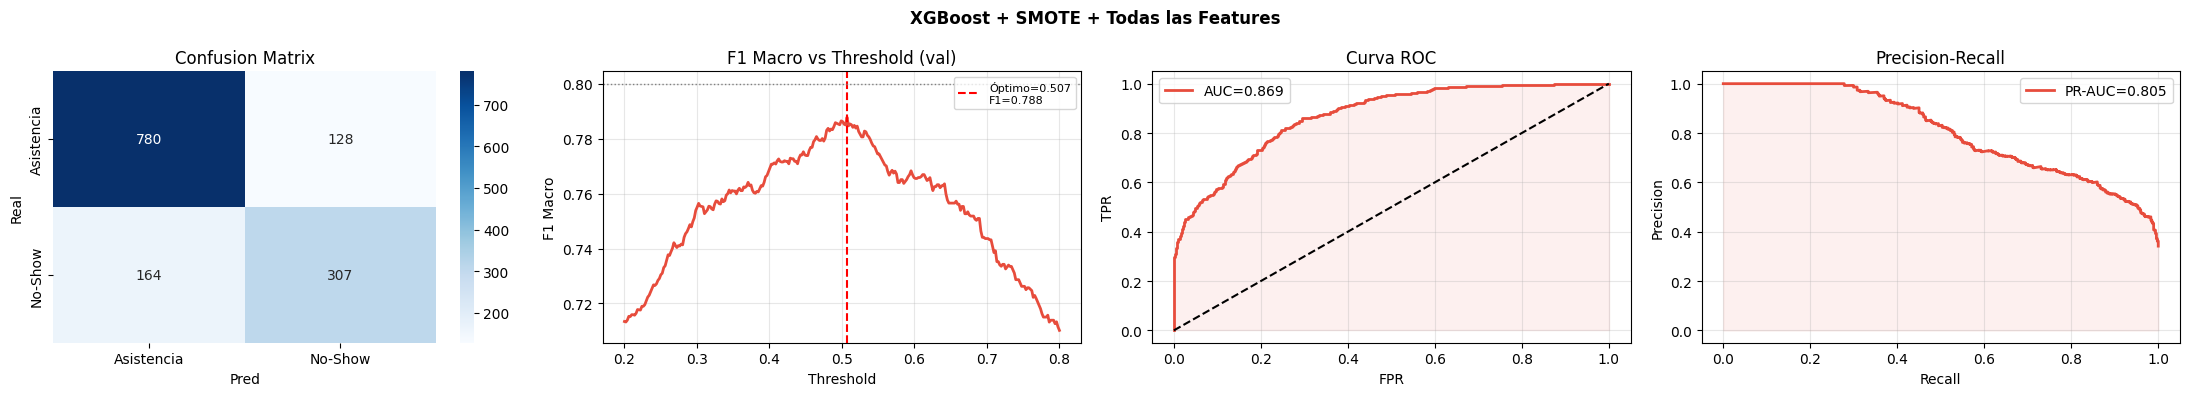

0.5070234113712375

In [6]:
# ============================================================
# 🚀 MODELO 1 — XGBoost  (n_iter=60)
# ============================================================
print('🚀 Entrenando XGBoost...')

cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

xgb_params = {
    'n_estimators':     [400, 600, 800, 1000, 1200],
    'max_depth':        [4, 5, 6, 7, 8],
    'learning_rate':    [0.01, 0.03, 0.05, 0.08, 0.1],
    'subsample':        [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],
    'gamma':            [0, 0.05, 0.1, 0.2, 0.3],
    'min_child_weight': [1, 3, 5, 7],
    'reg_lambda':       [0.5, 1, 2, 3, 5],
    'reg_alpha':        [0, 0.05, 0.1, 0.3, 0.5],
}

xgb_search = RandomizedSearchCV(
    XGBClassifier(objective='binary:logistic', eval_metric='logloss',
                  tree_method='hist', random_state=42, n_jobs=-1),
    xgb_params, n_iter=60, cv=cv5, scoring='f1_macro',
    n_jobs=-1, verbose=1, random_state=42
)
xgb_search.fit(X_tr, y_tr)

xgb_best = xgb_search.best_estimator_
print(f'\n   Mejor CV F1 Macro: {xgb_search.best_score_:.4f}')
print(f'   Params: {xgb_search.best_params_}')

evaluar('XGBoost + SMOTE + Todas las Features', xgb_best,
        X_val_sc, y_val, X_test_sc, y_test, color='#e74c3c')

In [ ]:
# ============================================================
# ⚡ MODELO 2 — LightGBM  (n_iter=60)
# ============================================================
print('⚡ Entrenando LightGBM...')

lgb_params = {
    'n_estimators':      [400, 600, 800, 1000, 1200],
    'max_depth':         [-1, 5, 7, 9, 12],
    'learning_rate':     [0.01, 0.03, 0.05, 0.08, 0.1],
    'num_leaves':        [20, 31, 50, 63, 80, 100],
    'subsample':         [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree':  [0.6, 0.7, 0.8, 0.9, 1.0],
    'min_child_samples': [10, 20, 30, 50],
    'reg_lambda':        [0, 0.1, 0.5, 1.0, 2.0, 3.0],
    'reg_alpha':         [0, 0.05, 0.1, 0.3, 0.5],
    'min_split_gain':    [0.0, 0.01, 0.05, 0.1],
}

lgb_search = RandomizedSearchCV(
    lgb.LGBMClassifier(objective='binary', random_state=42, n_jobs=-1, verbose=-1),
    lgb_params, n_iter=60, cv=cv5, scoring='f1_macro',
    n_jobs=-1, verbose=1, random_state=42
)
lgb_search.fit(X_tr, y_tr)

lgb_best = lgb_search.best_estimator_
print(f'\n   Mejor CV F1 Macro: {lgb_search.best_score_:.4f}')
print(f'   Params: {lgb_search.best_params_}')

evaluar('LightGBM + SMOTE + Todas las Features', lgb_best,
        X_val_sc, y_val, X_test_sc, y_test, color='#2ecc71')

⚡ Entrenando LightGBM...
Fitting 5 folds for each of 60 candidates, totalling 300 fits


🌿 Entrenando HistGradientBoosting...
Fitting 5 folds for each of 50 candidates, totalling 250 fits

   Mejor CV F1 Macro: 0.8583
   Params: {'min_samples_leaf': 10, 'max_leaf_nodes': 15, 'max_iter': 600, 'max_features': 0.8, 'max_depth': 12, 'learning_rate': 0.05, 'l2_regularization': 2.0, 'class_weight': None}

 🤖 HistGradientBoosting + SMOTE + Todas las Features
   Threshold óptimo (F1 macro en val) : 0.4528
   F1 macro en val al calibrar        : 0.7916

   Accuracy           : 0.7875  ⚠️
   Balanced Accuracy  : 0.7687
   F1 Macro           : 0.7660  ❌
   F1 Weighted        : 0.7885
   F1 No-Show (cls 1) : 0.6951
   Cohen's Kappa      : 0.5322
   ROC-AUC            : 0.8670
   PR-AUC             : 0.7992

                precision    recall  f1-score   support

Asistencia (0)     0.8459    0.8282    0.8370       908
   No-Show (1)     0.6816    0.7091    0.6951       471

      accuracy                         0.7875      1379
     macro avg     0.7638    0.7687    0.7660      1379


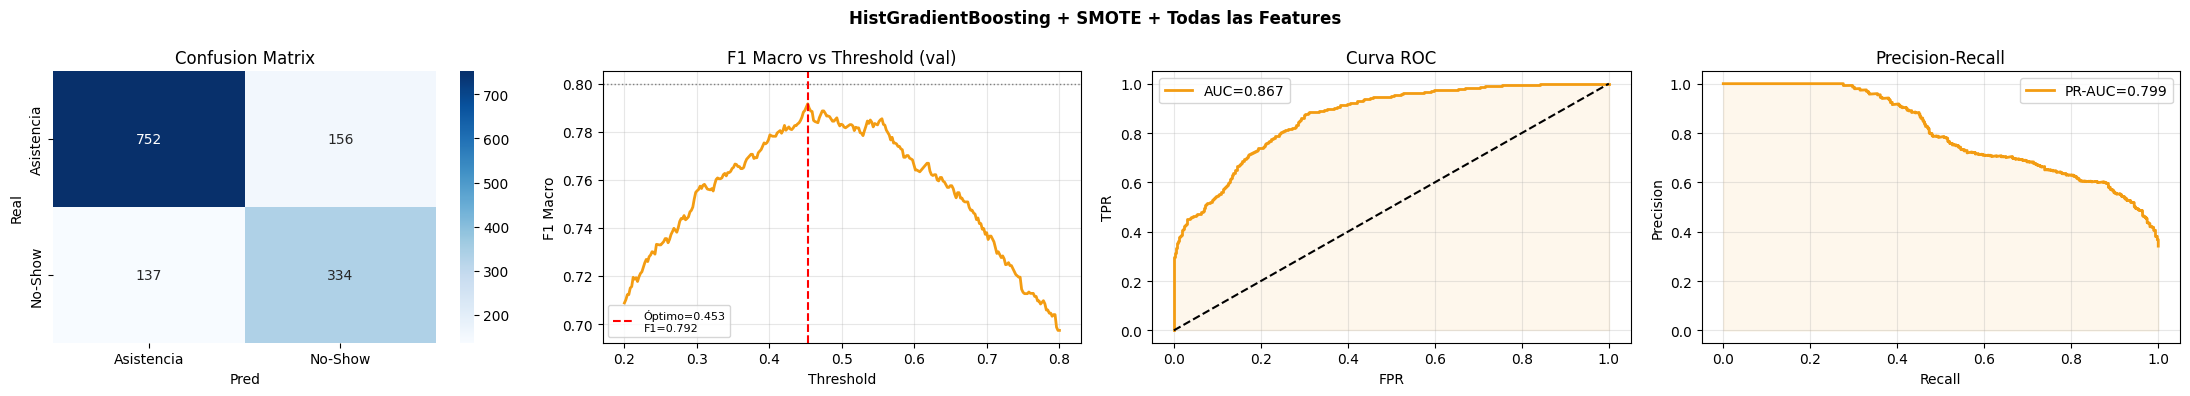

0.4528428093645485

In [ ]:
# ============================================================
# 🌿 MODELO 3 — HistGradientBoosting  (sklearn nativo, muy rápido)
# ============================================================
print('🌿 Entrenando HistGradientBoosting...')

hgb_params = {
    'max_iter':          [200, 400, 600, 800],
    'max_depth':         [None, 5, 7, 9, 12],
    'learning_rate':     [0.01, 0.03, 0.05, 0.08, 0.1],
    'max_leaf_nodes':    [15, 31, 50, 63, 80],
    'min_samples_leaf':  [10, 20, 30, 50],
    'l2_regularization': [0, 0.1, 0.5, 1.0, 2.0],
    'max_features':      [0.6, 0.8, 1.0],
    'class_weight':      [None, 'balanced'],
}

hgb_search = RandomizedSearchCV(
    HistGradientBoostingClassifier(random_state=42),
    hgb_params, n_iter=50, cv=cv5, scoring='f1_macro',
    n_jobs=-1, verbose=1, random_state=42
)
hgb_search.fit(X_tr, y_tr)

hgb_best = hgb_search.best_estimator_
print(f'\n   Mejor CV F1 Macro: {hgb_search.best_score_:.4f}')
print(f'   Params: {hgb_search.best_params_}')

evaluar('HistGradientBoosting + SMOTE + Todas las Features', hgb_best,
        X_val_sc, y_val, X_test_sc, y_test, color='#f39c12')

In [ ]:
# ============================================================
# 🌲 MODELO 4 — Random Forest  (n_iter=40)
# ============================================================
print('🌲 Entrenando Random Forest...')

rf_params = {
    'n_estimators':      [300, 500, 700, 1000],
    'max_depth':         [None, 10, 15, 20, 30],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf':  [1, 2, 5, 10],
    'max_features':      ['sqrt', 'log2', None],
    'class_weight':      [None, 'balanced', 'balanced_subsample'],
    'criterion':         ['gini', 'entropy'],
}

rf_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    rf_params, n_iter=40, cv=cv5, scoring='f1_macro',
    n_jobs=-1, verbose=1, random_state=42
)
rf_search.fit(X_tr, y_tr)

rf_best = rf_search.best_estimator_
print(f'\n   Mejor CV F1 Macro: {rf_search.best_score_:.4f}')
print(f'   Params: {rf_search.best_params_}')

evaluar('Random Forest + SMOTE + Todas las Features', rf_best,
        X_val_sc, y_val, X_test_sc, y_test, color='#3498db')

🌲 Entrenando Random Forest...
Fitting 5 folds for each of 40 candidates, totalling 200 fits


In [ ]:
# ============================================================
# 🏗️  MODELO 5 — STACKING ENSEMBLE
#    Combina XGBoost + LightGBM + HistGB como base
#    Meta-learner: Logistic Regression calibrada
# ============================================================
print('🏗️  Entrenando Stacking Ensemble...')

estimators_base = [
    ('xgb',  xgb_best),
    ('lgb',  lgb_best),
    ('hgb',  hgb_best),
]

stack = StackingClassifier(
    estimators=estimators_base,
    final_estimator=LogisticRegression(C=1.0, max_iter=1000, random_state=42),
    cv=5,
    stack_method='predict_proba',
    n_jobs=-1,
    passthrough=False,
)

stack.fit(X_tr, y_tr)
print('   ✅ Stacking entrenado!')

evaluar('Stacking (XGB + LGB + HGB) + SMOTE', stack,
        X_val_sc, y_val, X_test_sc, y_test, color='#8e44ad')

In [ ]:
# ============================================================
# 🏆 TABLA COMPARATIVA FINAL
# ============================================================

df_res = pd.DataFrame(resultados).sort_values('F1 Macro', ascending=False).reset_index(drop=True)
df_res.index = df_res.index + 1

print('\n' + '='*90)
print(' 🏆  RANKING FINAL — TODOS LOS MODELOS')
print('='*90)
display(df_res)

mejor = df_res.iloc[0]
print(f'\n🥇 MEJOR MODELO: {mejor["Modelo"]}')
print(f'   Accuracy  : {mejor["Accuracy"]*100:.2f}%  {mejor["Acc≥80%"]}')
print(f'   F1 Macro  : {mejor["F1 Macro"]*100:.2f}%  {mejor["F1≥80%"]}')
print(f'   ROC-AUC   : {mejor["ROC-AUC"]:.4f}')
print(f"   Kappa     : {mejor[\"Cohen's Kappa\"]:.4f}")
print(f'   Threshold : {mejor["Threshold"]}')

In [ ]:
# ============================================================
# 📊 IMPORTANCIA DE FEATURES — TOP 3 MODELOS
# ============================================================

modelos_fi = [
    ('XGBoost',            xgb_best),
    ('LightGBM',           lgb_best),
    ('HistGradientBoosting', hgb_best),
]

fig, axes = plt.subplots(1, 3, figsize=(20, 5))
fig.suptitle('Importancia de Features por Modelo', fontsize=14, fontweight='bold')

feature_cols = list(X_tr.columns) if hasattr(X_tr, 'columns') else [f'f{i}' for i in range(X_tr.shape[1])]

for ax, (nombre, modelo) in zip(axes, modelos_fi):
    fi = pd.Series(modelo.feature_importances_, index=feature_cols).sort_values(ascending=True).tail(15)
    fi.plot(kind='barh', ax=ax, color='#3498db')
    ax.set_title(nombre, fontweight='bold')
    ax.set_xlabel('Importancia')

plt.tight_layout()
plt.show()

# Importancia promedio entre los 3
fi_all = pd.DataFrame({
    nombre: pd.Series(modelo.feature_importances_, index=feature_cols)
    for nombre, modelo in modelos_fi
})
fi_all['Promedio'] = fi_all.mean(axis=1)
fi_all = fi_all.sort_values('Promedio', ascending=False)

print('\n📈 TOP 10 Features por importancia promedio entre modelos:')
display(fi_all.head(10))

In [ ]:
# ============================================================
# 📊 GRÁFICA COMPARATIVA DE MÉTRICAS
# ============================================================

metricas_plot = ['Accuracy', 'F1 Macro', 'F1 No-Show', 'ROC-AUC', 'Balanced Acc']
colores_m = ['#e74c3c', '#2ecc71', '#f39c12', '#3498db', '#8e44ad']

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Barras agrupadas
x = np.arange(len(metricas_plot))
n_mod = len(df_res)
width = 0.75 / n_mod

for i, (_, row) in enumerate(df_res.iterrows()):
    vals = [row[m] for m in metricas_plot]
    label = row['Modelo'].split(' ')[0]
    axes[0].bar(x + i*width, vals, width, label=label,
               color=colores_m[i % len(colores_m)], alpha=0.85)

axes[0].axhline(0.80, color='red', ls='--', lw=1.5, label='Objetivo 80%')
axes[0].set_xticks(x + width * n_mod / 2)
axes[0].set_xticklabels(metricas_plot, rotation=20, ha='right')
axes[0].set_ylim([0.55, 1.0])
axes[0].set_title('Métricas por Modelo', fontweight='bold')
axes[0].legend(fontsize=8, loc='lower right')
axes[0].grid(axis='y', alpha=0.3)

# Tabla de ranking horizontal
df_plot = df_res[['Modelo', 'Accuracy', 'F1 Macro', 'ROC-AUC']].copy()
df_plot['Modelo'] = df_plot['Modelo'].apply(lambda x: x.split(' ')[0])
df_plot.set_index('Modelo').plot(kind='barh', ax=axes[1],
                                  color=['#e74c3c','#2ecc71','#3498db'], alpha=0.85)
axes[1].axvline(0.80, color='red', ls='--', lw=1.5)
axes[1].set_xlim([0.50, 1.0])
axes[1].set_title('Ranking Acc / F1 / ROC-AUC', fontweight='bold')
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

# ── Guardar resultados ────────────────────────────────────────
out_dir = Path('../data/processed')
if not out_dir.exists():
    out_dir = Path('data/processed')
out_dir.mkdir(parents=True, exist_ok=True)
df_res.to_csv(out_dir / 'resultados_alta_performance.csv')
print(f'\n💾 Resultados guardados en: {(out_dir / "resultados_alta_performance.csv").resolve()}')

print('\n' + '='*70)
print(' ✅ RESUMEN EJECUTIVO')
print('='*70)
for _, row in df_res.iterrows():
    cumple = '✅ CUMPLE OBJETIVO' if row['Acc≥80%'] == '✅' and '✅' in row['F1≥80%'] else '⚠️  CERCA' if row['Acc≥80%'] == '✅' or '⚠️' in row['F1≥80%'] else '❌'
    print(f"   {row['Modelo']:<45} Acc={row['Accuracy']:.3f}  F1={row['F1 Macro']:.3f}  → {cumple}")